In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv("cardekho_data.csv")
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [50]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [51]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

In [52]:
df["Owner"].unique()

array([0, 1, 3])

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [54]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [55]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [56]:
df.duplicated().sum()

np.int64(2)

In [57]:
df.drop_duplicates(inplace=True)

In [58]:
df.duplicated().sum()

np.int64(0)

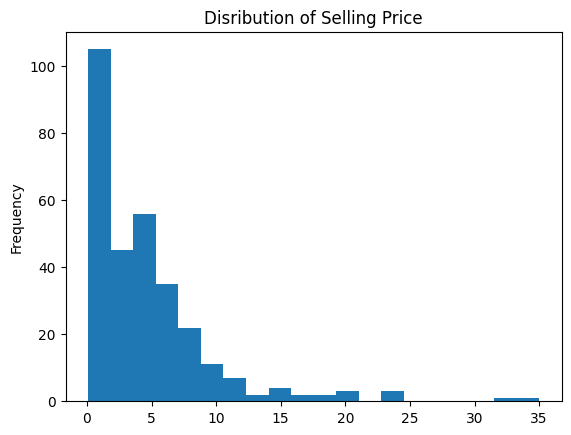

In [59]:
df["Selling_Price"].plot(kind="hist", bins=20, title="Disribution of Selling Price")
plt.show()

In [60]:
df["Fuel_Type"].unique()

<StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str

In [61]:
fuel_type_avg_price = df.groupby("Fuel_Type")["Selling_Price"].mean()
fuel_type_avg_price.sort_values(ascending=False)

Fuel_Type
Diesel    10.102759
Petrol     3.264184
CNG        3.100000
Name: Selling_Price, dtype: float64

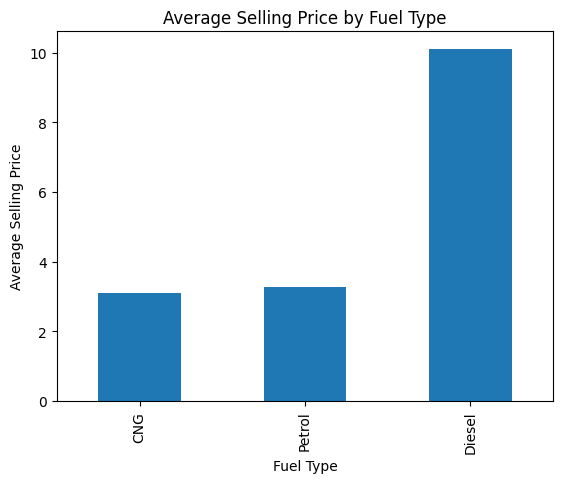

In [62]:
fuel_type_avg_price.sort_values(ascending=True).plot(kind="bar", title="Average Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price")
plt.show()

In [63]:
transmission_counts = df["Transmission"].value_counts()

In [64]:
transmission_counts

Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

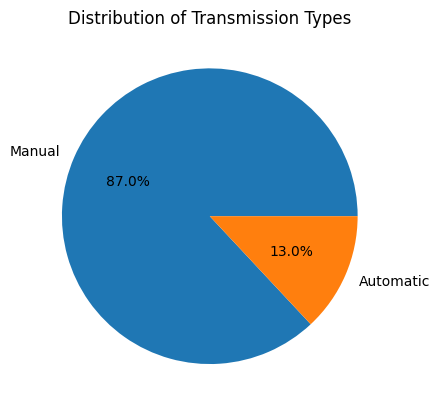

In [65]:
transmission_counts.plot(kind="pie", autopct="%1.1f%%", title="Distribution of Transmission Types")
plt.ylabel("")
plt.show()

In [66]:
seller_type_total_present_price = df.groupby("Seller_Type")["Present_Price"].sum()

In [67]:
seller_type_total_present_price

Seller_Type
Dealer        2081.43
Individual     173.34
Name: Present_Price, dtype: float64

In [68]:
yearly_avg_kms_driven = df.groupby("Year")["Kms_Driven"].mean()

In [69]:
yearly_avg_kms_driven.sort_values(ascending=False)

Year
2004    135154.000000
2008    112128.571429
2005    104294.000000
2003     94500.000000
2006     87422.250000
2009     67820.500000
2010     60014.066667
2007     51000.000000
2012     43798.217391
2013     41534.333333
2011     40327.368421
2014     38080.315789
2015     31977.683333
2016     17885.040816
2017     10419.800000
2018      2071.000000
Name: Kms_Driven, dtype: float64

In [70]:
fuel_trans_max_selling_price = df.groupby(["Fuel_Type","Transmission"])["Selling_Price"].max()

In [71]:
fuel_trans_max_selling_price.reset_index()

,Fuel_Type,Transmission,Selling_Price
0,CNG,Manual,3.25
1,Diesel,Automatic,33.00
2,Diesel,Manual,35.00
3,Petrol,Automatic,19.75
4,Petrol,Manual,17.00


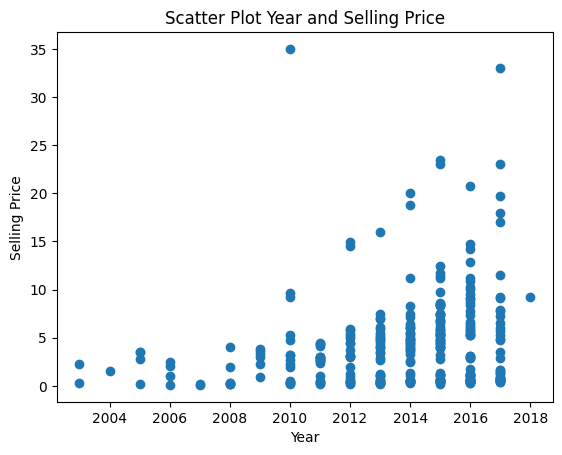

In [72]:
plt.scatter(df["Year"],df["Selling_Price"])
plt.title("Scatter Plot Year and Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price")
plt.show()

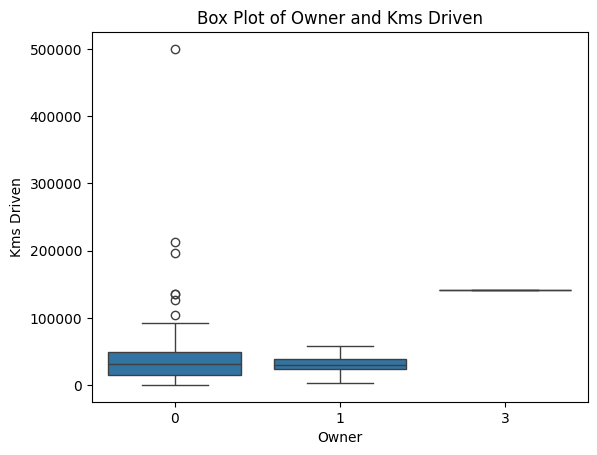

In [73]:
sns.boxplot(x="Owner", y="Kms_Driven", data=df)
plt.title("Box Plot of Owner and Kms Driven")
plt.xlabel("Owner")
plt.ylabel("Kms Driven")
plt.show()

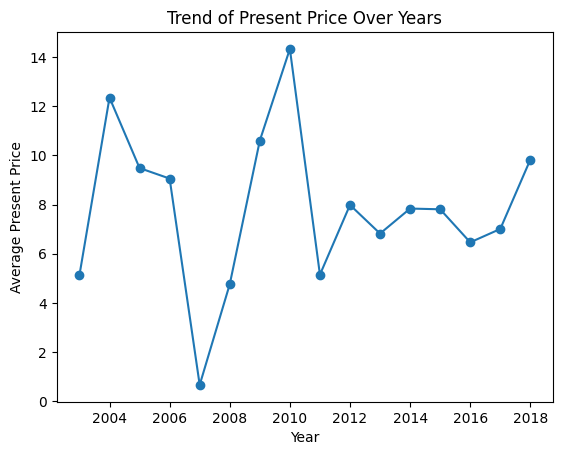

In [74]:
plt.plot(df.groupby("Year")["Present_Price"].mean(), marker="o")
plt.title("Trend of Present Price Over Years")
plt.xlabel("Year")
plt.ylabel("Average Present Price")
plt.show()

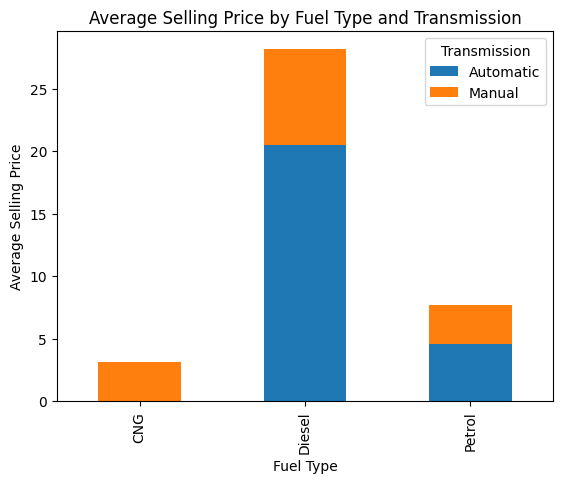

In [75]:
df.groupby(["Fuel_Type","Transmission"])["Selling_Price"].mean().unstack().plot(kind="bar",stacked=True)
plt.title("Average Selling Price by Fuel Type and Transmission")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price")
plt.show()

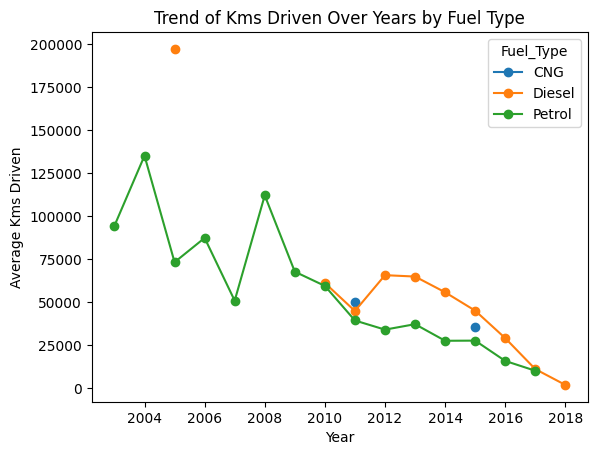

In [76]:
df.groupby(["Year","Fuel_Type"])["Kms_Driven"].mean().unstack().plot(kind="line",marker="o")
plt.title("Trend of Kms Driven Over Years by Fuel Type")
plt.xlabel("Year")
plt.ylabel("Average Kms Driven")
plt.show()

In [77]:
df.groupby(["Year","Fuel_Type"])["Kms_Driven"].mean().unstack()

Fuel_Type,CNG,Diesel,Petrol
Year,,,
2003,NaN,NaN,94500.000000
2004,NaN,NaN,135154.000000
2005,NaN,197176.000000,73333.333333
2006,NaN,NaN,87422.250000
2007,NaN,NaN,51000.000000
2008,NaN,NaN,112128.571429
2009,NaN,NaN,67820.500000
2010,NaN,61256.000000,59562.454545
2011,49998.0,45000.000000,39483.647059


In [78]:
y = df["Selling_Price"]

In [79]:
X = df[["Year","Kms_Driven","Fuel_Type","Transmission","Owner"]]

In [80]:
X

,Year,Kms_Driven,Fuel_Type,Transmission,Owner
0,2014,27000,Petrol,Manual,0
1,2013,43000,Diesel,Manual,0
2,2017,6900,Petrol,Manual,0
3,2011,5200,Petrol,Manual,0
4,2014,42450,Diesel,Manual,0
...,...,...,...,...,...
296,2016,33988,Diesel,Manual,0
297,2015,60000,Petrol,Manual,0
298,2009,87934,Petrol,Manual,0
299,2017,9000,Diesel,Manual,0


In [81]:
from sklearn import preprocessing
labelencoder = preprocessing.LabelEncoder()

In [82]:
X["Fuel_Type"] = labelencoder.fit_transform(X["Fuel_Type"])
X["Transmission"] = labelencoder.fit_transform(X["Transmission"])

In [83]:
X

,Year,Kms_Driven,Fuel_Type,Transmission,Owner
0,2014,27000,2,1,0
1,2013,43000,1,1,0
2,2017,6900,2,1,0
3,2011,5200,2,1,0
4,2014,42450,1,1,0
...,...,...,...,...,...
296,2016,33988,1,1,0
297,2015,60000,2,1,0
298,2009,87934,2,1,0
299,2017,9000,1,1,0


In [84]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [85]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.fit_transform(X_test)

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def modelresults(predictions):
    print("Mean absolute error is {}".format(mean_absolute_error(y_test, predictions)))
    print("Root mean squared error is {}".format(np.sqrt(mean_squared_error(y_test, predictions))))

In [93]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(scaled_X_train, y_train)
predslr = lr.predict(scaled_X_test)
modelresults(predslr)

Mean absolute error is 2.9895785945932323
Root mean squared error is 4.989350237172953


In [108]:
from sklearn.metrics import r2_score
r2_score(y_test,predslr)

0.1796578700702519

In [94]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

In [96]:
svrmodel = SVR()
param_gridsvr = {"C" : [0.1,0.5], "kernel" : ["linear","rbf","poly"], "degree":[2,3,4]}

In [97]:
gridsvr = GridSearchCV(svrmodel, param_gridsvr)

In [98]:
gridsvr.fit(scaled_X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 0.5], 'degree': [2, 3, ...], 'kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of information printe

In [99]:
gridsvr.best_params_

{'C': 0.1, 'degree': 2, 'kernel': 'linear'}

In [100]:
predsgridsvr = gridsvr.predict(scaled_X_test)

In [101]:
modelresults(predsgridsvr)

Mean absolute error is 2.8760234549351527
Root mean squared error is 4.936301092797363


In [109]:
r2_score(y_test,predsgridsvr)

0.19700966604080394

In [102]:
from sklearn.ensemble import RandomForestRegressor

In [103]:
rfrmodel = RandomForestRegressor()
param_gridrfr = {"max_depth": [5,10], "n_estimators":[2,5,8]}
gridrfr = GridSearchCV(rfrmodel, param_gridrfr)

In [104]:
gridrfr.fit(scaled_X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10], 'n_estimators': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of information printed dur

In [105]:
gridrfr.best_params_

{'max_depth': 5, 'n_estimators': 8}

In [106]:
predsgridrfr = gridrfr.predict(scaled_X_test)

In [107]:
modelresults(predsgridrfr)

Mean absolute error is 2.6419756981763594
Root mean squared error is 4.9760168399104545


In [110]:
r2_score(y_test,predsgridrfr)

0.18403652935885573